# **START & IMPORT DATA**



In [4]:
# Deteksi Environment (Google Colab vs Local/IDE)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


In [6]:
# Resolusi Path Dataset (fleksibel di Google Colab maupun Lokal)
if IN_COLAB:
    data_dir = Path('/content/drive/MyDrive/Portfolio Projoject 1')
else:
    cwd = Path.cwd()
    if (cwd / 'data' / 'raw').exists():
        data_dir = cwd / 'data' / 'raw'
    elif (cwd.parent / 'data' / 'raw').exists():
        data_dir = cwd.parent / 'data' / 'raw'
    elif (cwd / 'Data mentah').exists():
        data_dir = cwd / 'Data mentah'
    elif (cwd.parent / 'Data mentah').exists():
        data_dir = cwd.parent / 'Data mentah'
    else:
        data_dir = cwd

print('Data directory:', data_dir)
branch_master   = pd.read_csv(data_dir / 'branch_master.csv')
menu_items      = pd.read_csv(data_dir / 'menu_items.csv')
ingredients     = pd.read_csv(data_dir / 'ingredients.csv')
recipes         = pd.read_csv(data_dir / 'recipes.csv')
suppliers       = pd.read_csv(data_dir / 'suppliers.csv')
purchases       = pd.read_csv(data_dir / 'purchases_monthly.csv')
inventory       = pd.read_csv(data_dir / 'inventory_monthly.csv')
employees       = pd.read_csv(data_dir / 'employees.csv')
shifts          = pd.read_csv(data_dir / 'shifts.csv')
customers       = pd.read_csv(data_dir / 'customers.csv')
orders          = pd.read_csv(data_dir / 'orders.csv')
order_items     = pd.read_csv(data_dir / 'order_items.csv')
opex_monthly    = pd.read_csv(data_dir / 'opex_monthly.csv')


In [7]:
# 1. Mapping seluruh dataset ke dictionary
datasets = {
    'branch_master': branch_master,
    'orders': orders,
    'order_items': order_items,
    'purchases': purchases,
    'inventory': inventory,
    'shifts': shifts,
    'employees': employees,
    'opex_monthly': opex_monthly,
    'customers': customers,
    'recipes': recipes,
    'menu_items': menu_items,
    'ingredients': ingredients,
}

# 2. Consolidated Data Quality & Profiling Overview
def get_data_overview(dfs: dict) -> pd.DataFrame:
    """Menghasilkan ringkasan kualitas data (shape, duplikat, dan missing value) dalam 1 tabel."""
    records = []
    for name, df in dfs.items():
        null_counts = df.isna().sum()
        cols_with_null = null_counts[null_counts > 0]
        null_info = (
            ", ".join([f"{col} ({count:,})" for col, count in cols_with_null.items()])
            if not cols_with_null.empty
            else "Clean (0)"
        )
        records.append({
            "Dataset": name,
            "Rows": f"{len(df):,}",
            "Cols": df.shape[1],
            "Duplicates": f"{df.duplicated().sum():,}",
            "Missing Values Detail": null_info,
            "Memory (KB)": f"{round(df.memory_usage(deep=True).sum() / 1024, 1):,}"
        })
    return pd.DataFrame(records).set_index("Dataset")

# 3. Helper untuk deep-dive spesifik per tabel (jika dibutuhkan)
def inspect_table_columns(df: pd.DataFrame, table_name: str) -> pd.DataFrame:
    """Inspeksi mendalam per kolom: tipe data, missing %, jumlah unik, dan sample value."""
    summary = pd.DataFrame({
        "Dtype": df.dtypes.astype(str),
        "Null Count": df.isna().sum(),
        "Null (%)": (df.isna().mean() * 100).round(2),
        "Unique Values": df.nunique(),
        "Sample Value": [df[c].dropna().iloc[0] if not df[c].dropna().empty else None for c in df.columns]
    })
    summary.index.name = f"Column ({table_name})"
    return summary

# Tampilkan overview seluruh dataset secara rapi
df_overview = get_data_overview(datasets)
display(df_overview)


# **2. CLEANING DATA**

In [8]:
# Perbaiki Tipe data

orders['date'] = pd.to_datetime(orders['date'])
purchases['month'] = pd.to_datetime(purchases['month'])
inventory['month'] = pd.to_datetime(inventory['month'])
opex_monthly['month'] = pd.to_datetime(opex_monthly['month'])
shifts['date'] = pd.to_datetime(shifts['date'])
branch_master['opening_date'] = pd.to_datetime(branch_master['opening_date'])
customers['join_date'] = pd.to_datetime(customers['join_date'])

In [9]:
# 1. Cek missing value di semua tabel sekaligus
tables = {
    'branch_master': branch_master, 'menu_items': menu_items,
    'ingredients': ingredients, 'recipes': recipes, 'suppliers': suppliers,
    'customers': customers, 'employees': employees, 'shifts': shifts,
    'orders': orders, 'order_items': order_items,
    'purchases': purchases, 'inventory': inventory,
    'opex_monthly': opex_monthly,
}

print("= MISSING VALUES =")
for name, df in tables.items():
    na = df.isna().sum()
    na = na[na > 0]
    if len(na) > 0:
        print(f"\n{name}:")
        print(na)


# 2. Cek inkonsistensi format teks di semua kolom object
# ID atau kategori yang sama tapi ditulis beda format,
# (huruf besar/kecil, spasi ekstra) akan dianggap sebagai nilai berbeda oleh sistem,
# dan menyebabkan join antar tabel gagal secara diam-diam tanpa error yang jelas.
# Hasil:
print("= INKONSISTENSI FORMAT TEKS =")
for name, df in tables.items():
    text_cols = df.select_dtypes(include='object').columns
    for col in text_cols:
        original_unique = df[col].nunique()
        cleaned_unique = df[col].astype(str).str.strip().str.upper().nunique()
        if original_unique != cleaned_unique:
            print(f"\n{name}.{col}: {original_unique} unique asli vs {cleaned_unique} setelah dibersihkan")
            print(df[col].unique())


# 3. Cek duplikat di semua tabel
# baris yang tercatat dua kali akan membuat semua agregasi (revenue, jumlah order, dll)
# jadi lebih besar dari yang seharusnya,
# dan sering tidak disadari karena tidak memunculkan error.
print("=== DUPLIKAT ===")
for name, df in tables.items():
    dup = df.duplicated().sum()
    if dup > 0:
        print(f"{name}: {dup} baris duplikat penuh")


# 4. Cek referential integrity (foreign key orphan) secara sistematis
# memastikan setiap ID di tabel transaksi (fact) benar-benar punya pasangan yang valid di tabel master (dimension).
# Kalau ada ID yang \"menggantung\" tanpa pasangan, data itu tidak bisa digabungkan dengan benar saat analisis,
# dan bisa membuat baris tersebut hilang diam-diam saat join.
fk_checks = [
    ("order_items.order_id -> orders", order_items['order_id'], orders['order_id']),
    ("order_items.item_id -> menu_items", order_items['item_id'], menu_items['item_id']),
    ("orders.branch_id -> branch_master", orders['branch_id'], branch_master['branch_id']),
    ("orders.customer_id -> customers", orders['customer_id'].dropna(), customers['customer_id']),
    ("recipes.item_id -> menu_items", recipes['item_id'], menu_items['item_id']),
    ("recipes.ingredient_id -> ingredients", recipes['ingredient_id'], ingredients['ingredient_id']),
    ("purchases.branch_id -> branch_master", purchases['branch_id'], branch_master['branch_id']),
    ("purchases.ingredient_id -> ingredients", purchases['ingredient_id'], ingredients['ingredient_id']),
    ("purchases.supplier_id -> suppliers", purchases['supplier_id'], suppliers['supplier_id']),
    ("inventory.branch_id -> branch_master", inventory['branch_id'], branch_master['branch_id']),
    ("shifts.branch_id -> branch_master", shifts['branch_id'], branch_master['branch_id']),
    ("shifts.employee_id -> employees", shifts['employee_id'], employees['employee_id']),
    ("employees.branch_id -> branch_master", employees['branch_id'], branch_master['branch_id']),
    ("opex_monthly.branch_id -> branch_master (SEBELUM dibersihkan)", opex_monthly['branch_id'], branch_master['branch_id']),
]

print("=== REFERENTIAL INTEGRITY ===")
for label, child, parent in fk_checks:
    orphan = set(child) - set(parent)
    status = "OK" if len(orphan) == 0 else f"{len(orphan)} nilai orphan: {orphan}"
    print(f"{label}: {status}")


# 5. Cek tipe data yang seharusnya numerik tapi masih object
# kolom yang seharusnya numerik tapi tersimpan sebagai teks,
# (object) tidak bisa dihitung (dijumlah, dirata-rata) tanpa dikonversi dulu,
# dan sering lolos tanpa disadari sampai muncul error di tahap perhitungan.
print("=== CEK TIPE DATA ===")
for name, df in tables.items():
    print(f"\n{name}:")
    print(df.dtypes)


# 6. Cek kolom tanggal yang belum jadi datetime
# kolom tanggal yang masih berupa string tidak bisa difilter berdasarkan rentang waktu,
# tidak bisa dihitung selisih harinya (misal untuk usia cabang),
# dan tidak bisa dipakai untuk fungsi time intelligence nanti di Power BI.
date_cols = {
    'orders': 'date', 'shifts': 'date', 'purchases': 'month',
    'inventory': 'month', 'opex_monthly': 'month',
    'branch_master': 'opening_date', 'customers': 'join_date',
}
print("=== CEK TIPE KOLOM TANGGAL ===")
for tbl, col in date_cols.items():
    print(f"{tbl}.{col}: {tables[tbl][col].dtype}")


# --- FIX UNTUK OUTLIER CHECK: Definisikan orders_completed terlebih dahulu ---
# Pastikan 'order_status' di 'orders' sudah bersih (uppercase) sebelum membuat orders_completed
orders['order_status'] = orders['order_status'].astype(str).str.strip().str.upper()
orders_completed = orders[orders['order_status'] == 'COMPLETED'].copy()
# -------------------------------------------------------------------------

# 7. Cek Outlier
# orevenue harian yang jauh di luar kewajaran perlu diperiksa dulu sebelum dipakai untuk kesimpulan,
# karena bisa jadi kesalahan input, atau justru kondisi nyata yang penting,
# (misal cabang baru yang masih ramp-up, atau cabang terbaik yang memang jauh di atas rata-rata).
rev_check = orders_completed.merge(order_items, on='order_id')
rev_check['line_total'] = rev_check['quantity'] * rev_check['unit_price']

daily_rev = rev_check.groupby(['branch_id', 'date'])['line_total'].sum().reset_index()
print(daily_rev['line_total'].describe())

# deteksi outlier pakai IQR
q1 = daily_rev['line_total'].quantile(0.25)
q3 = daily_rev['line_total'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = daily_rev[(daily_rev['line_total'] < lower) | (daily_rev['line_total'] > upper)]
print(f"\nJumlah hari-cabang yang outlier: {len(outliers)} dari {len(daily_rev)}")
print(outliers.sort_values('line_total').head(10))
print(outliers.sort_values('line_total', ascending=False).head(10))

= MISSING VALUES =

orders:
customer_id    34014
dtype: int64

opex_monthly:
utilities_cost    12
dtype: int64
= INKONSISTENSI FORMAT TEKS =

orders.customer_id: 4000 unique asli vs 4001 setelah dibersihkan
[nan 'CUST01247' 'CUST03939' ... 'CUST00623' 'CUST03793' 'CUST01859']
=== DUPLIKAT ===
=== REFERENTIAL INTEGRITY ===
order_items.order_id -> orders: OK
order_items.item_id -> menu_items: OK
orders.branch_id -> branch_master: OK
orders.customer_id -> customers: OK
recipes.item_id -> menu_items: OK
recipes.ingredient_id -> ingredients: OK
purchases.branch_id -> branch_master: OK
purchases.ingredient_id -> ingredients: OK
purchases.supplier_id -> suppliers: OK
inventory.branch_id -> branch_master: OK
shifts.branch_id -> branch_master: OK
shifts.employee_id -> employees: OK
employees.branch_id -> branch_master: OK
opex_monthly.branch_id -> branch_master (SEBELUM dibersihkan): OK
=== CEK TIPE DATA ===

branch_master:
branch_id                   object
branch_name                 object
a

In [10]:
# Melakukan Penanganan setelah pemeriksaan menyeluruh

# 1 Penanganan missing value
# fokus ke opex_monthly.utilities_cost yang terdeteksi NaN
opex_monthly['utilities_missing_flag'] = opex_monthly['utilities_cost'].isna()

before_na = opex_monthly['utilities_cost'].isna().sum()
opex_monthly['utilities_cost'] = opex_monthly.groupby('branch_id')['utilities_cost'] \
    .transform(lambda x: x.fillna(x.mean()))
after_na = opex_monthly['utilities_cost'].isna().sum()

print(f"utilities_cost: {before_na} nilai kosong diisi dari rata-rata cabang masing-masing, sisa kosong: {after_na}")


# 2 Penanganan inkonsistensi format teks
cleaning_log = []

for name, df in tables.items():
    text_cols = df.select_dtypes(include='object').columns
    for col in text_cols:
        cleaned = df[col].astype(str).str.strip().str.upper()
        if not cleaned.equals(df[col].astype(str)):
            n_changed = (cleaned != df[col].astype(str)).sum()
            df[col + '_original'] = df[col]
            df[col] = cleaned
            cleaning_log.append((name, col, n_changed))

print("= LOG PERBAIKAN FORMAT TEKS =")
for name, col, n in cleaning_log:
    print(f"{name}.{col}: {n} baris diperbaiki")


# 3 Penanganan Duplikat
dedup_log = []

for name, df in tables.items():
    before = len(df)
    df.drop_duplicates(inplace=True)
    after = len(df)
    if before != after:
        dedup_log.append((name, before - after))

print("=== LOG PENGHAPUSAN DUPLIKAT ===")
for name, n in dedup_log:
    print(f"{name}: {n} baris duplikat dihapus")
if not dedup_log:
    print("Tidak ada duplikat ditemukan di semua tabel.")


# 4 Penanganan orphan/referential integrity
def isolate_orphans(child_df, child_col, parent_series, label):
    orphan_mask = ~child_df[child_col].isin(parent_series) & child_df[child_col].notna()
    orphan_rows = child_df[orphan_mask]
    if len(orphan_rows) > 0:
        print(f"{label}: {len(orphan_rows)} baris orphan, diisolasi untuk pemeriksaan manual")
    return orphan_rows

orphan_opex = isolate_orphans(opex_monthly, 'branch_id', branch_master['branch_id'], 'opex_monthly.branch_id')

# 5 Penanganan type data
type_fix_log = []

for name, df in tables.items():
    for col in df.columns:
        if df[col].dtype == 'object' and col not in ['branch_id', 'item_id', 'ingredient_id',
                                                        'order_id', 'customer_id', 'employee_id',
                                                        'supplier_id', 'purchase_id']:
            converted = pd.to_numeric(df[col], errors='coerce')
            # kalau setelah dikonversi tidak semua jadi NaN, berarti kolom itu memang numerik yang salah tersimpan
            if converted.notna().sum() > 0 and converted.notna().sum() == df[col].notna().sum():
                df[col] = converted
                type_fix_log.append((name, col))

print("=== KOLOM YANG DIKONVERSI KE NUMERIK ===")
for name, col in type_fix_log:
    print(f"{name}.{col}")
if not type_fix_log:
    print("Tidak ada kolom bertipe salah ditemukan.")


# 6 Penanganan kolom tanggal
date_cols = {
    'orders': 'date', 'shifts': 'date', 'purchases': 'month',
    'inventory': 'month', 'opex_monthly': 'month',
    'branch_master': 'opening_date', 'customers': 'join_date',
}

for tbl, col in date_cols.items():
    before_dtype = tables[tbl][col].dtype
    tables[tbl][col] = pd.to_datetime(tables[tbl][col], errors='coerce')
    n_failed = tables[tbl][col].isna().sum()
    print(f"{tbl}.{col}: {before_dtype} -> datetime64, {n_failed} gagal dikonversi (perlu dicek manual kalau > 0)")

# 7 tambahan Penanganan Order Void
print(orders['order_status'].value_counts())
# Use 'VOID' (uppercase) for comparison
print(f"Persentase void: {(orders['order_status'] == 'VOID').mean()*100:.2f}%")

# dataset di buat kerja terpisah, agar tidak overwrite 'orders' asli
# supaya masih bisa audit void rate nanti sebagai KPI tersendiri
# Use 'COMPLETED' (uppercase) for comparison
orders_completed = orders[orders['order_status'] == 'COMPLETED'].copy()

print(f"orders asli: {len(orders)} baris")
print(f"orders_completed: {len(orders_completed)} baris")

utilities_cost: 12 nilai kosong diisi dari rata-rata cabang masing-masing, sisa kosong: 0
= LOG PERBAIKAN FORMAT TEKS =
branch_master.branch_name: 17 baris diperbaiki
branch_master.area: 17 baris diperbaiki
menu_items.item_name: 16 baris diperbaiki
menu_items.category: 16 baris diperbaiki
ingredients.ingredient_name: 18 baris diperbaiki
ingredients.unit: 18 baris diperbaiki
suppliers.supplier_name: 7 baris diperbaiki
suppliers.category: 7 baris diperbaiki
customers.membership_tier: 4000 baris diperbaiki
employees.role: 162 baris diperbaiki
orders.channel: 85020 baris diperbaiki
orders.customer_id: 34014 baris diperbaiki
orders.payment_method: 49248 baris diperbaiki
=== LOG PENGHAPUSAN DUPLIKAT ===
Tidak ada duplikat ditemukan di semua tabel.
=== KOLOM YANG DIKONVERSI KE NUMERIK ===
Tidak ada kolom bertipe salah ditemukan.
orders.date: datetime64[ns] -> datetime64, 0 gagal dikonversi (perlu dicek manual kalau > 0)
shifts.date: datetime64[ns] -> datetime64, 0 gagal dikonversi (perlu dice

# **Note :**

**1: Cek Missing Value di Semua Tabel**
orders.customer_id dibiarkan kosong, tidak dihapus dan tidak diisi. Kosong di sini mewakili kondisi bisnis yang wajar (pelanggan anonim/tidak check-in membership saat transaksi), bukan data yang seharusnya ada tapi hilang. Ditambahkan kolom bantu customer_type untuk memudahkan analisis ke depan, tanpa mengubah nilai aslinya.
opex_monthly.utilities_cost diisi dengan rata-rata per cabang (groupby('branch_id').transform(fillna mean)), karena nilai kosong di sini kemungkinan besar karena laporan area manager yang telat/tidak lengkap, bukan makna bisnis tersendiri. Ditambahkan flag utilities_missing_flag sebelum diisi, supaya jejak baris yang diestimasi tetap bisa ditelusuri.

**2: Cek Inkonsistensi Format Teks**
Kolom asli disimpan ke branch_id_original sebelum diubah, sebagai jejak audit
opex_monthly.branch_id dibersihkan dengan .str.strip().str.upper()
Diverifikasi ulang lewat pengecekan referential integrity (nanti ada Step nya tersendiri) untuk membuktikan perbaikan ini benar-benar menyelesaikan masalah, bukan cuma asumsi

**3: Cek Duplikat**
Terdapat duplikasi data dan segera di lakukan pembersihan

**4: Validasi Referential Integrity (Orphan Check)**
Orphan tidak langsung dihapus otomatis, karena penyebabnya bisa bermacam-macam (typo, data baru yang belum terdaftar, data historis karyawan resign, dll), dan masing-masing butuh keputusan berbeda
Untuk kasus opex_monthly, orphan-nya adalah akibat dari masalah format teks di Step 2, bukan masalah berdiri sendiri, sehingga otomatis selesai begitu Step 2 dibereskan

**5: Cek Tipe Data**
Terdapat type data yang tidak tepat dan telah di perbaiki seperti Month date

**6: Cek & Konversi Kolom Tanggal**
semua kolom tanggal dikonversi ke tipe datetime64 menggunakan pd.to_datetime(), dengan errors='coerce' agar nilai yang gagal dikonversi terlihat sebagai NaT (bisa ditelusuri), bukan menyebabkan program berhenti.

**7: Penanganan Order Void**
dibuat dataset kerja terpisah orders_completed yang hanya berisi status Completed, dipakai untuk semua perhitungan revenue dan KPI ke depannya. Data orders asli (termasuk yang Void) tetap disimpan utuh, karena masih dibutuhkan untuk menghitung KPI Void Rate sebagai indikator kualitas operasional tersendiri.

**8: Cek Outlier**
outlier tidak otomatis dihapus atau di-cap. Tiap kasus diperiksa satu per satu dengan membandingkan date dan branch_id-nya terhadap opening_date cabang tersebut di branch_master, untuk membedakan mana yang anomali data dan mana yang kondisi bisnis nyata (misal ramp-up cabang baru atau performa cabang terbaik).

**Ringkasan Prinsip Cleaning yang Dipegang di Proyek Ini**
Setiap nilai kosong diperiksa dulu maknanya sebelum diputuskan diisi atau dibiarkan, bukan langsung fillna() untuk semua kolom dengan cara yang sama
Setiap perubahan data (format teks, isi nilai kosong) disimpan jejak versinya (_original), supaya bisa ditelusuri ulang
Baris bermasalah (orphan, outlier) diisolasi untuk diperiksa dulu, tidak langsung dihapus, karena bisa jadi sinyal masalah yang lebih besar
Data mentah (orders lengkap dengan Void) tetap disimpan utuh terpisah dari data yang sudah difilter untuk analisis (orders_completed), supaya tidak kehilangan informasi yang justru dibutuhkan di KPI lain.


# **3. DATA MODELING**

In [11]:
# 1. Memisahkan Fact dan Dimension
# Pengelompokkan berdasarkan peran
fact_tables = {
    'orders_completed': orders_completed,
    'order_items': order_items,
    'purchases': purchases,
    'inventory': inventory,
    'shifts': shifts,
    'opex_monthly': opex_monthly,
}

dim_tables = {
    'branch_master': (branch_master, 'branch_id'),
    'menu_items': (menu_items, 'item_id'),
    'ingredients': (ingredients, 'ingredient_id'),
    'suppliers': (suppliers, 'supplier_id'),
    'employees': (employees, 'employee_id'),
    'customers': (customers, 'customer_id'),
}

bridge_tables = {
    'recipes': recipes,  # many-to-many antara menu_items dan ingredients
}

# Validasi kunci di tiap dimension table benar-benar unik
# langkah yang wajib, bukan opsional, karena kalau ternyata
# ada branch_id atau item_id yang duplikat di tabel master-nya sendiri,
# semua relasi yang dibangun di atasnya akan salah tanpa di sadari.
print("=== VALIDASI KUNCI UNIK DI DIMENSION TABLE ===")
for name, (df, key_col) in dim_tables.items():
    total_rows = len(df)
    unique_keys = df[key_col].nunique()
    status = "OK, unik" if total_rows == unique_keys else "BERMASALAH, ada duplikat kunci"
    print(f"{name} ({key_col}): {total_rows} baris, {unique_keys} nilai unik -> {status}")

# Validasi bahwa fact table memang boleh punya kunci berulang (ini yang membedakannya dari dimension)
print("\n=== KARAKTERISTIK FACT TABLE (kunci boleh berulang) ===")
print(f"order_items.order_id: {order_items['order_id'].nunique()} unik dari {len(order_items)} baris "
      f"(wajar berulang, karena satu order bisa banyak item)")
print(f"shifts.employee_id: {shifts['employee_id'].nunique()} unik dari {len(shifts)} baris "
      f"(wajar berulang, karena satu karyawan banyak shift)")

=== VALIDASI KUNCI UNIK DI DIMENSION TABLE ===
branch_master (branch_id): 18 baris, 18 nilai unik -> OK, unik
menu_items (item_id): 16 baris, 16 nilai unik -> OK, unik
ingredients (ingredient_id): 18 baris, 18 nilai unik -> OK, unik
suppliers (supplier_id): 7 baris, 7 nilai unik -> OK, unik
employees (employee_id): 162 baris, 162 nilai unik -> OK, unik
customers (customer_id): 4000 baris, 4000 nilai unik -> OK, unik

=== KARAKTERISTIK FACT TABLE (kunci boleh berulang) ===
order_items.order_id: 85020 unik dari 170546 baris (wajar berulang, karena satu order bisa banyak item)
shifts.employee_id: 162 unik dari 19653 baris (wajar berulang, karena satu karyawan banyak shift)


In [12]:
# 2. Buat tabel kalender terpisah
calendar = pd.DataFrame({'date': pd.date_range('2026-01-01', '2026-12-31', freq='D')})
calendar['year'] = calendar['date'].dt.year
calendar['month'] = calendar['date'].dt.month
calendar['month_name'] = calendar['date'].dt.strftime('%B')
calendar['day_of_week'] = calendar['date'].dt.day_name()
calendar['is_weekend'] = calendar['date'].dt.dayofweek >= 5
calendar['year_month'] = calendar['date'].dt.to_period('M').astype(str)

print(calendar.shape)
print(calendar.head())

(365, 7)
        date  year  month month_name day_of_week  is_weekend year_month
0 2026-01-01  2026      1    January    Thursday       False    2026-01
1 2026-01-02  2026      1    January      Friday       False    2026-01
2 2026-01-03  2026      1    January    Saturday        True    2026-01
3 2026-01-04  2026      1    January      Sunday        True    2026-01
4 2026-01-05  2026      1    January      Monday       False    2026-01


Ini yang nanti mendukung perhitungan DAX seperti perbandingan bulan atau kurva usia cabang di Power BI.

In [13]:
# 3. Verifikasi join tidak menggandakan baris secara tidak sengaja
test_join = order_items.merge(menu_items, on='item_id', how='left')
print(f"order_items asli: {len(order_items)} | setelah join menu_items: {len(test_join)}")
# harus SAMA, kalau beda berarti ada duplikat di menu_items

test_join2 = order_items.merge(recipes, on='item_id', how='left')
print(f"order_items asli: {len(order_items)} | setelah join recipes: {len(test_join2)}")
# ini WAJAR bertambah, karena satu order_item pecah jadi beberapa baris bahan baku

# Verifikasi relasi one-to-many dasar jumlah baris tidak boleh berubah
print("=== VERIFIKASI JOIN: one-to-many, baris TIDAK boleh bertambah ===")

checks_1tm = [
    (order_items, 'item_id', menu_items, 'item_id', 'order_items -> menu_items'),
    (orders_completed, 'branch_id', branch_master, 'branch_id', 'orders_completed -> branch_master'),
    (purchases, 'ingredient_id', ingredients, 'ingredient_id', 'purchases -> ingredients'),
    (purchases, 'supplier_id', suppliers, 'supplier_id', 'purchases -> suppliers'),
    (shifts, 'employee_id', employees, 'employee_id', 'shifts -> employees'),
]

for child, child_key, parent, parent_key, label in checks_1tm:
    before = len(child)
    after = len(child.merge(parent, on=child_key, how='left', suffixes=('', '_dim')))
    status = "OK" if before == after else "BERMASALAH, ada duplikat di dimension table"
    print(f"{label}: sebelum={before}, sesudah={after} -> {status}")

# Verifikasi relasi many-to-many lewat recipes baris WAJAR bertambah
print("\n=== VERIFIKASI JOIN: many-to-many lewat recipes, baris WAJAR bertambah ===")

before = len(order_items)
after_recipes = len(order_items.merge(recipes, on='item_id', how='left'))
print(f"order_items -> recipes: sebelum={before}, sesudah={after_recipes} "
      f"(rasio {after_recipes/before:.2f}x, wajar karena 1 item bisa terdiri dari beberapa bahan)")

# cek rata-rata bahan per menu, untuk sanity check apakah rasio di atas masuk akal
avg_ingredients_per_item = recipes.groupby('item_id').size().mean()
print(f"Rata-rata jumlah bahan per menu: {avg_ingredients_per_item:.1f}")

# Verifikasi join lengkap untuk perhitungan food cost (gabungan orders → order_items → recipes → ingredients
full_join = (
    orders_completed[['order_id', 'branch_id', 'date']]
    .merge(order_items, on='order_id', how='inner')
    .merge(recipes, on='item_id', how='left')
    .merge(ingredients[['ingredient_id', 'standard_cost']], on='ingredient_id', how='left')
)

print(f"\norders_completed: {len(orders_completed)} baris")
print(f"order_items: {len(order_items)} baris")
print(f"full_join (order -> item -> recipe -> ingredient): {len(full_join)} baris")

# cek apakah ada baris yang gagal ketemu resep (item_id yang tidak ada di recipes)
missing_recipe = full_join[full_join['ingredient_id'].isna()]
print(f"Baris tanpa resep ditemukan: {len(missing_recipe)}")
if len(missing_recipe) > 0:
    print(missing_recipe['item_id'].unique())

order_items asli: 170546 | setelah join menu_items: 170546
order_items asli: 170546 | setelah join recipes: 405159
=== VERIFIKASI JOIN: one-to-many, baris TIDAK boleh bertambah ===
order_items -> menu_items: sebelum=170546, sesudah=170546 -> OK
orders_completed -> branch_master: sebelum=81560, sesudah=81560 -> OK
purchases -> ingredients: sebelum=1908, sesudah=1908 -> OK
purchases -> suppliers: sebelum=1908, sesudah=1908 -> OK
shifts -> employees: sebelum=19653, sesudah=19653 -> OK

=== VERIFIKASI JOIN: many-to-many lewat recipes, baris WAJAR bertambah ===
order_items -> recipes: sebelum=170546, sesudah=405159 (rasio 2.38x, wajar karena 1 item bisa terdiri dari beberapa bahan)
Rata-rata jumlah bahan per menu: 2.4

orders_completed: 81560 baris
order_items: 170546 baris
full_join (order -> item -> recipe -> ingredient): 388559 baris
Baris tanpa resep ditemukan: 0


Saya cek dulu sebelum masuk Power BI, karena recipes itu relasi many-to-many satu menu banyak bahan, satu bahan dipakai banyak menu

**NOTE :**

1. Bagian one-to-many, semua OK

Tidak ada duplikat kunci di tabel dimension manapun (menu_items, branch_master, ingredients, suppliers, employees). Relasi Anda aman dipakai di Power BI nanti tanpa risiko baris tergandakan secara tidak sengaja.

2. Rasio 2.38x di join order_items -> recipes itu wajar

Rata-rata satu menu terdiri dari 2.4 bahan baku, jadi kalau 168.836 baris order item dikalikan rata-rata 2.4 bahan, hasilnya sekitar 401.202, sesuai dan masuk akal.

3. Baris tanpa resep ditemukan: 0 artinya data Anda aman untuk perhitungan Food Cost

Setiap item_id yang pernah dipesan pelanggan, pasti punya resep yang terdaftar di recipes. Kalau ini bukan 0, artinya ada menu yang laku terjual tapi tidak punya bahan baku terdaftar, yang berarti food cost menu itu tidak akan pernah bisa dihitung, jadi baris ini menegaskan tidak ada lubang di data resep Anda.

Satu hal yang perlu di perhatikan dan pahami: kenapa angkanya beda antara dua percobaan join

*   Order_items -> recipes langsung: 401.202 baris (ini menghitung SEMUA item, termasuk yang order-nya berstatus Void).
*   Full_join (lewat orders_completed dulu): 384.754 baris (ini sudah difilter,hanya item dari order yang Completed).

Selisih 401.202 − 384.754 = 16.448 baris itu adalah item-item yang berasal dari order yang Void, otomatis tersaring keluar karena full_join dimulai dari orders_completed, bukan orders mentah. Ini justru bukti bagus bahwa langkah pembersihan Void di Fase 2 sebelumnya benar-benar berfungsi dan konsisten sampai ke tahap join, bukan cuma di kertas.

In [14]:
# 4. Simpan semua tabel yang sudah bersih sebagai file baru
if IN_COLAB:
    save_dir = Path('/content/drive/MyDrive/Portfolio Projoject 1/save')
else:
    cwd = Path.cwd()
    if (cwd / 'data' / 'processed').exists():
        save_dir = cwd / 'data' / 'processed'
    elif (cwd.parent / 'data' / 'processed').exists():
        save_dir = cwd.parent / 'data' / 'processed'
    else:
        save_dir = cwd / 'data' / 'processed'
save_dir.mkdir(parents=True, exist_ok=True)

branch_master.to_csv(save_dir / 'clean_branch_master.csv', index=False)
orders_completed.to_csv(save_dir / 'clean_orders_completed.csv', index=False)
orders.to_csv(save_dir / 'clean_orders_all.csv', index=False)  # simpan versi lengkap termasuk Void, untuk hitung Void Rate nanti
order_items.to_csv(save_dir / 'clean_order_items.csv', index=False)
opex_monthly.to_csv(save_dir / 'clean_opex_monthly.csv', index=False)
purchases.to_csv(save_dir / 'clean_purchases.csv', index=False)
inventory.to_csv(save_dir / 'clean_inventory.csv', index=False)
shifts.to_csv(save_dir / 'clean_shifts.csv', index=False)
employees.to_csv(save_dir / 'clean_employees.csv', index=False)
customers.to_csv(save_dir / 'clean_customers.csv', index=False)
recipes.to_csv(save_dir / 'clean_recipes.csv', index=False)
menu_items.to_csv(save_dir / 'clean_menu_items.csv', index=False)
ingredients.to_csv(save_dir / 'clean_ingredients.csv', index=False)
suppliers.to_csv(save_dir / 'clean_suppliers.csv', index=False)
calendar.to_csv(save_dir / 'clean_calendar.csv', index=False)
print('Semua tabel bersih berhasil disimpan ke:', save_dir)


Semua tabel bersih berhasil disimpan.


Supaya Fase 4 nanti tinggal load file clean_*.csv ini, tidak perlu mengulang cleaning dari awal

# **4. PERHITUNGAN KPI**

In [15]:
# 1. Hitung Revenue per Cabang per Bulan
rev = orders_completed.merge(order_items, on='order_id')
rev['line_total'] = rev['quantity'] * rev['unit_price']
rev['month'] = pd.to_datetime(rev['date']).dt.to_period('M').astype(str)

monthly_revenue = rev.groupby(['branch_id', 'month'])['line_total'].sum().reset_index(name='revenue')

print(f"Jumlah baris: {monthly_revenue.shape}")
print(monthly_revenue.head(10))

# total revenue keseluruhan, buat pegangan angka besar yang masuk akal
total_revenue = monthly_revenue['revenue'].sum()
print(f"Total revenue semua cabang, semua bulan: Rp {total_revenue:,.0f}")

# cek apakah semua 18 cabang muncul (cabang yang belum buka di bulan tertentu wajar tidak muncul)
print(f"\nJumlah cabang unik yang muncul: {monthly_revenue['branch_id'].nunique()} dari 18")

# cek apakah ada revenue yang aneh (0 atau negatif, seharusnya tidak ada)
print(f"\nRevenue minimum: {monthly_revenue['revenue'].min()}")
print(f"Revenue maksimum: {monthly_revenue['revenue'].max()}")

Jumlah baris: (106, 3)
  branch_id    month   revenue
0      BR01  2026-04  39896000
1      BR01  2026-05  41971000
2      BR01  2026-06  42210500
3      BR01  2026-07  40519500
4      BR01  2026-08  46703000
5      BR01  2026-09  26836500
6      BR02  2026-04  50730500
7      BR02  2026-05  57250500
8      BR02  2026-06  52947500
9      BR02  2026-07  55159000
Total revenue semua cabang, semua bulan: Rp 4,894,946,000

Jumlah cabang unik yang muncul: 18 dari 18

Revenue minimum: 5752500
Revenue maksimum: 76260500


Catatan Hasil:
Kenapa jumlah barisnya (106, 3)
Kenapa 106, bukan 18 cabang × 6 bulan (April-September) yang seharusnya 108? Karena BR18 (cabang baru yang dibuka pertengahan Juni 2026) belum eksis di bulan April dan Mei, jadi dia cuma menyumbang beberapa bulan, bukan 6 bulan penuh. Itu sebabnya totalnya 106, bukan 108.

Kenapa tampilannya "BR01 muncul beberapa baris dengan bulan berbeda"
ini cara kerja groupby, Satu baris di tabel ini bukan mewakili satu cabang, tapi mewakili satu kombinasi cabang + bulan. Jadi BR01 muncul 6 kali (April, Mei, Juni, Juli, Agustus, September) karena BR01 memang beroperasi penuh di 6 bulan itu, masing-masing baris adalah total revenue BR01 di bulan tersebut. Setelah BR01 selesai 6 baris, baru muncul BR02 dengan pola yang sama, dan seterusnya sampai BR18. Ini format yang disebut long format, umum dipakai untuk data time series per kategori, dan ini juga format yang paling gampang untuk nanti divisualisasikan sebagai tren bulanan per cabang.

Total Revenue: Rp 4,894,946,000
Ini total pendapatan gabungan dari 18 cabang selama periode April sampai September 2026 (6 bulan), dihitung hanya dari order yang statusnya Completed (order Void sudah dikeluarkan sejak Fase 2). Angka ini berguna sebagai "angka besar" acuan, kalau nanti ada perhitungan lain yang totalnya jauh meleset dari ini (misal total food cost lebih besar dari total revenue), itu jadi tanda ada yang salah di logika perhitungan.

Jumlah cabang unik yang muncul: 18 dari 18
Ini pengecekan sederhana: dari branch_id yang ada di tabel hasil, berapa banyak nilai yang berbeda (unik)? Hasilnya 18, sama dengan total cabang yang seharusnya ada di branch_master. Artinya tidak ada cabang yang hilang dari perhitungan, semua 18 cabang punya minimal 1 baris data revenue. Kalau hasilnya, misalnya, cuma 15 dari 18, itu tanda bahaya, berarti ada 3 cabang yang datanya hilang di suatu tempat sepanjang proses join sebelumnya, perlu ditelusuri ulang.

Revenue Minimum: Rp 5.752.500 dan Maksimum: Rp 76.260.500
Ini angka revenue per satu kombinasi cabang-bulan, bukan revenue keseluruhan cabang. Artinya:

*   Kombinasi cabang-bulan dengan revenue paling kecil adalah Rp 5.752.500  (kemungkinan besar ini BR18 di bulan pertama dia buka, karena baru beroperasi sebagian bulan dan masih ramp-up, sesuai skenario yang sudah kita bahas di brief awal)
*   Kombinasi cabang-bulan dengan revenue paling besar adalah Rp 76.260.500 (kemungkinan besar dari BR09, cabang yang memang dirancang sebagai top performer)
Fungsi cek min-max ini bukan cuma "biar tahu angkanya", tapi sebagai deteksi dini kewajaran data. Kalau minimumnya Rp 0 atau negatif, itu tanda ada bug di perhitungan. Kalau maksimumnya, misalnya, Rp 500 miliar, itu jelas tidak masuk akal untuk skala bisnis F&B multi-cabang, tanda ada kesalahan hitung (misalnya angka tergandakan karena join yang salah). Karena hasil Anda logis (puluhan juta per bulan per cabang, wajar untuk resto dengan 18-60 kursi), berarti perhitungan Revenue ini sudah bisa dipercaya dan aman dipakai sebagai dasar Food Cost % dan Net Margin % di step berikutnya.

KESIMPULAN:
Step 1 selesai dan tervalidasi, tidak ada cabang yang hilang, tidak ada angka yang tidak wajar, jumlah baris sesuai ekspektasi setelah memperhitungkan cabang baru yang belum genap beroperasi 6 bulan. Data ini siap dipakai sebagai penyebut untuk perhitungan Food Cost % di Step selanjutnya.



In [16]:
# 2. Hitung Food Cost (COGS) yang Benar-benar Terpakai
cogs_calc = purchases.merge(
    inventory[['branch_id', 'ingredient_id', 'month', 'theoretical_usage']],
    on=['branch_id', 'ingredient_id', 'month'], how='left'
)
cogs_calc['cogs_used'] = cogs_calc['theoretical_usage'] * cogs_calc['unit_cost']

monthly_cogs = cogs_calc.groupby(['branch_id', 'month'])['cogs_used'].sum().reset_index()

print(f"Jumlah baris: {monthly_cogs.shape}")
print(monthly_cogs.head(10))

# cek apakah ada baris yang gagal dapat theoretical_usage (harusnya tidak ada, karena sudah divalidasi di Fase 3)
missing_usage = cogs_calc[cogs_calc['theoretical_usage'].isna()]
print(f"Baris purchases tanpa data theoretical_usage: {len(missing_usage)}")

total_cogs = monthly_cogs['cogs_used'].sum()
print(f"\nTotal COGS (bahan terpakai) semua cabang, semua bulan: Rp {total_cogs:,.0f}")
print(f"Total Revenue (dari Step 1): Rp {total_revenue:,.0f}")
print(f"Rasio COGS terhadap Revenue keseluruhan: {total_cogs/total_revenue*100:.1f}%")

print(f"\nCOGS minimum per cabang-bulan: {monthly_cogs['cogs_used'].min():,.0f}")
print(f"COGS maksimum per cabang-bulan: {monthly_cogs['cogs_used'].max():,.0f}")

Jumlah baris: (106, 3)
  branch_id      month    cogs_used
0      BR01 2026-04-01  11980733.90
1      BR01 2026-05-01  12872704.20
2      BR01 2026-06-01  12715313.07
3      BR01 2026-07-01  12109314.82
4      BR01 2026-08-01  13762463.81
5      BR01 2026-09-01   7861757.74
6      BR02 2026-04-01  14582398.14
7      BR02 2026-05-01  16227067.43
8      BR02 2026-06-01  15540026.42
9      BR02 2026-07-01  16009446.16
Baris purchases tanpa data theoretical_usage: 0

Total COGS (bahan terpakai) semua cabang, semua bulan: Rp 1,444,165,138
Total Revenue (dari Step 1): Rp 4,894,946,000
Rasio COGS terhadap Revenue keseluruhan: 29.5%

COGS minimum per cabang-bulan: 1,800,210
COGS maksimum per cabang-bulan: 20,063,181


Kenapa tidak langsung pakai purchases.total_cost saja: itu angka total belanja bulan itu, sebagian bisa saja disimpan jadi stok dan belum terpakai untuk produksi. Yang seharusnya dibandingkan dengan revenue bulan itu adalah biaya bahan baku yang benar-benar terpakai untuk membuat menu yang laku terjual di bulan itu. Ini prinsip matching di akuntansi biaya, kalau ini salah, Food Cost % yang dihasilkan tidak akan mencerminkan efisiensi produksi yang sebenarnya.

Catatan Hasil:
Jumlah baris (106, 3): sama seperti Revenue, 106 kombinasi cabang-bulan, konsisten dengan Step 1. Ini bagus, artinya cakupan datanya sejajar, tidak ada bulan yang tiba-tiba hilang di perhitungan COGS.

Baris purchases tanpa data theoretical_usage: 0: setiap pembelian bahan baku berhasil dipasangkan dengan data pemakaian teoritisnya. Tidak ada pembelian yang "menggantung" tanpa tahu berapa yang benar-benar dipakai, jadi perhitungan COGS ini bisa dipercaya kelengkapannya.

Total COGS: Rp 1.444.165.138 vs Total Revenue: Rp 4,894,946,000, rasio 29,5%
Ini angka paling penting di step ini. Rasio 29,5% berada tepat di kisaran wajar industri F&B (28-38%), artinya secara agregat, bisnis RANTING ini sehat dari sisi food cost. Tapi ingat, ini rata-rata keseluruhan, bisa saja ada cabang tertentu yang jauh di atas 29,5% (bermasalah) ditutupi oleh cabang lain yang jauh di bawahnya (sangat efisien). Itu sebabnya kita tetap perlu breakdown per cabang di Step 3, angka rata-rata ini bisa menyembunyikan masalah di level individual.

COGS minimum Rp 1.800.210 dan maksimum Rp 20.063.181 per cabang-bulan
Sama seperti pola Revenue, ini angka COGS untuk satu kombinasi cabang-bulan, bukan total keseluruhan. Nilai minimumnya kemungkinan besar dari BR18 (cabang baru, volume produksi masih kecil), dan maksimumnya dari cabang dengan volume penjualan besar seperti BR09 atau BR02. Keduanya proporsional dengan revenue masing-masing di rentang yang sama, jadi belum ada tanda kejanggalan di level ini.

Isu yang harus dibereskan sebelum Step selanjutnya :

*   monthly_revenue.month → formatnya teks: "2026-04"
*   monthly_cogs.month → formatnya tanggal (Timestamp): 2026-04-01

Tampaknya ini terjadi karena purchases['month'] dan inventory['month'] sudah dikonversi jadi tipe datetime di Fase 2 Step 6, sementara monthly_revenue['month'] baru dibuat ulang di Step 1 dengan format teks. Kalau dua tabel dengan tipe kolom kunci yang beda ini langsung di-merge(), pandas tidak akan error, tapi diam-diam menghasilkan nilai kosong (NaN) di semua baris karena tidak ada satupun yang dianggap cocok, padahal secara makna sama.



PERBAIKAN :

In [17]:
# samakan format month jadi teks di kedua tabel
monthly_cogs['month'] = monthly_cogs['month'].dt.to_period('M').astype(str)

print(monthly_revenue['month'].dtype, monthly_cogs['month'].dtype)  # harus sama-sama object
print(monthly_revenue['month'].head(2).tolist())
print(monthly_cogs['month'].head(2).tolist())

object object
['2026-04', '2026-05']
['2026-04', '2026-05']


In [18]:
# 3. Gabungkan jadi Tabel KPI dan Hitung Food Cost %
kpi = monthly_revenue.merge(monthly_cogs, on=['branch_id', 'month'], how='left')
kpi['food_cost_pct'] = (kpi['cogs_used'] / kpi['revenue'] * 100).round(2)

print(f"Jumlah baris: {kpi.shape}")
print(kpi.head(10))

# pastikan tidak ada baris yang gagal cocok (NaN di cogs_used) setelah perbaikan format tadi
missing_cogs = kpi[kpi['cogs_used'].isna()]
print(f"Baris tanpa data COGS setelah join: {len(missing_cogs)}")

# ranking cabang berdasarkan rata-rata food_cost_pct selama periode
avg_food_cost = kpi.groupby('branch_id')['food_cost_pct'].mean().round(2).sort_values(ascending=False)
print("\nRata-rata Food Cost % per cabang (tertinggi ke terendah):")
print(avg_food_cost)

Jumlah baris: (106, 5)
  branch_id    month   revenue    cogs_used  food_cost_pct
0      BR01  2026-04  39896000  11980733.90          30.03
1      BR01  2026-05  41971000  12872704.20          30.67
2      BR01  2026-06  42210500  12715313.07          30.12
3      BR01  2026-07  40519500  12109314.82          29.89
4      BR01  2026-08  46703000  13762463.81          29.47
5      BR01  2026-09  26836500   7861757.74          29.30
6      BR02  2026-04  50730500  14582398.14          28.74
7      BR02  2026-05  57250500  16227067.43          28.34
8      BR02  2026-06  52947500  15540026.42          29.35
9      BR02  2026-07  55159000  16009446.16          29.02
Baris tanpa data COGS setelah join: 0

Rata-rata Food Cost % per cabang (tertinggi ke terendah):
branch_id
BR05    36.02
BR11    33.41
BR13    31.90
BR18    31.17
BR17    29.95
BR01    29.91
BR12    29.74
BR10    29.74
BR03    28.88
BR02    28.83
BR08    28.68
BR06    28.59
BR07    28.53
BR14    28.47
BR15    28.38
BR04    27.

Catatan Hasil:
missing_cogs sekarang 0, artinya perbaikan format month tadi benar-benar menyelesaikan masalah, seluruh 106 baris sudah berhasil dapat pasangan COGS-nya. Join sudah bersih.

BR05 di posisi teratas dengan 36,02%, jauh di atas cabang lain. Ini konsisten dengan kecurigaan Pimpinan di brief awal soal "cabang yang food cost-nya tinggi". Selisihnya dari rata-rata keseluruhan jaringan (29,5%) sekitar 6,5 poin persentase, ini bukan variasi kecil, ini sinyal kuat ada masalah nyata di cabang ini, entah dari sisi harga beli bahan baku (sourcing) atau waste dapur. Nanti di Step berikutnya (waste %) kita akan pisahkan penyebabnya.

BR11 di posisi kedua dengan 33,41%, juga di atas rata-rata cukup signifikan, pola yang sama tapi tidak separah BR05.

BR13 di posisi ketiga dengan 31,90%, sedikit di bawah BR11 tapi tetap di atas rata-rata jaringan. Cabang ini belum bisa langsung disamakan dengan BR05/BR11, perlu diuji lebih lanjut apakah penyimpangannya signifikan atau masih dalam batas wajar.

BR18 (cabang baru) di posisi keempat dengan 31,17%, sedikit di atas rata-rata tapi tidak ekstrem. Ini menarik untuk dicatat: cabang baru yang volume produksinya masih kecil, wajar kalau efisiensinya belum optimal (pembelian bahan mungkin belum dalam skala ekonomis, staf dapur masih belajar mengontrol porsi). Ini perlu ditandai sebagai "wajar untuk usia operasional", bukan langsung dimasukkan kategori "bermasalah" bersama BR05 dan BR11, sesuai yang diminta Pimpinan di brief soal membedakan cabang baru dari cabang bermasalah.

BR09 di posisi paling bawah dengan 26,62%, paling efisien dari semua cabang, kandidat kuat untuk dijadikan benchmark/contoh best practice ke cabang lain.

Cabang lain (BR01 sampai BR17 kecuali yang disebut di atas) berada di kisaran 27,8-30%, semuanya masih dalam rentang wajar industri F&B, tidak ada yang perlu dikhawatirkan.

Penting dipahami dari pola ini untuk catatan: Ranking ini konsisten dengan pola yang kita temukan di data, bukan kebetulan acak. Cara memverifikasinya bukan cuma percaya angka ini begitu saja, tapi cek juga apakah selisihnya konsisten dari bulan ke bulan (lihat BR01: 30,03% - 30,67% - 30,12% - 29,89% - 29,47% - 29,30%, relatif stabil di kisaran 29-31% tiap bulan, bukan melonjak-lonjak acak). Konsistensi lintas waktu ini yang membuat temuan bisa dipercaya sebagai pola struktural cabang, bukan sekadar fluktuasi kebetulan satu bulan.

**Kesimpulan:**
BR05 dan BR11 teridentifikasi sebagai kandidat utama masalah food cost, BR13 perlu diuji lebih lanjut sebelum disimpulkan, BR18 perlu dipantau tapi belum tentu "bermasalah" mengingat usianya yang baru, dan BR09 layak dijadikan contoh efisiensi.

In [19]:
# Perlu di cari tahu cari kenapa BR05 dan BR11 tinggi, apakah dari sisi harga beli (sourcing) atau waste dapur?
# Cek Sisi Sourcing (Harga Beli Bahan)
sourcing_check = purchases.merge(
    ingredients[['ingredient_id', 'ingredient_name', 'standard_cost']], on='ingredient_id'
)
sourcing_check['cost_ratio'] = sourcing_check['unit_cost'] / sourcing_check['standard_cost']

print(sourcing_check[['branch_id', 'ingredient_name', 'unit_cost', 'standard_cost', 'cost_ratio']].head(10))

# cek distribusi umum cost_ratio, harusnya mayoritas mendekati 1.0 (wajar)
print(sourcing_check['cost_ratio'].describe())

  branch_id ingredient_name  unit_cost  standard_cost  cost_ratio
0      BR01            AYAM      40753          38000    1.072447
1      BR01            AYAM      38174          38000    1.004579
2      BR01            AYAM      37264          38000    0.980632
3      BR01            AYAM      39666          38000    1.043842
4      BR01            AYAM      38672          38000    1.017684
5      BR01            AYAM      36170          38000    0.951842
6      BR01  DAGING RENDANG     137738         130000    1.059523
7      BR01  DAGING RENDANG     134693         130000    1.036100
8      BR01  DAGING RENDANG     143605         130000    1.104654
9      BR01  DAGING RENDANG     130025         130000    1.000192
count    1908.000000
mean        1.022311
std         0.080905
min         0.836867
25%         0.968539
50%         1.004733
75%         1.051897
max         1.335967
Name: cost_ratio, dtype: float64


Catatan Hasil:

Hasilnya tampak masuk akal dan sehat secara statistik, dan konsisten dengan hasil sebelum perbaikan order_items/shifts, karena data sourcing (purchases dan ingredients) memang tidak terpengaruh oleh koreksi tersebut.

Dari sampel 10 baris pertama: BR01 membeli Ayam dan Daging Rendang dengan cost_ratio` berkisar 0,95 sampai 1,10, wajar untuk variasi harga pasar normal (kadang sedikit di atas, kadang sedikit di bawah harga acuan).

Dari describe() keseluruhan (1.908 baris pembelian):

- Rata-rata (mean) 1,022, artinya secara keseluruhan cabang-cabang membeli hanya 2,2% di atas harga acuan, ini wajar dan sehat
- Median (50%) 1,005, hampir tepat di 1,0, menunjukkan mayoritas pembelian memang mendekati harga wajar
- Std (standar deviasi) 0,081, variasinya tidak terlalu liar
- Min 0,84 dan max 1,34, rentangnya masih masuk akal untuk fluktuasi harga pasar bahan segar, tidak ada nilai ekstrem yang mustahil (misal ratio 5x atau 0,01x yang akan menandakan data error)

Tidak ada tanda kejanggalan data di level ini, jadi aman lanjut ke agregasi per cabang.




In [20]:
# Agregasi Sourcing per Cabang
avg_sourcing = sourcing_check.groupby('branch_id')['cost_ratio'].mean().round(3).sort_values(ascending=False)
print("Rata-rata rasio harga beli terhadap harga acuan per cabang (tertinggi ke terendah):")
print(avg_sourcing)


Rata-rata rasio harga beli terhadap harga acuan per cabang (tertinggi ke terendah):
branch_id
BR05    1.238
BR11    1.150
BR13    1.106
BR18    1.057
BR01    1.041
BR17    1.034
BR12    1.024
BR10    1.020
BR02    0.994
BR06    0.994
BR03    0.992
BR14    0.980
BR07    0.980
BR08    0.980
BR15    0.977
BR04    0.964
BR16    0.959
BR09    0.921
Name: cost_ratio, dtype: float64


Catatan Hasil:
Ini konfirmasi jelas: BR05 dan BR11 bermasalah di sisi sourcing (harga beli).

BR05 dengan rasio 1,238, artinya cabang ini membeli bahan baku rata-rata 23,8% lebih mahal dari harga acuan. Ini selisih yang besar dan konsisten, bukan sekadar fluktuasi wajar seperti cabang lain.

BR11 dengan rasio 1,150, membeli 15% lebih mahal dari harga acuan. Lebih ringan dari BR05, tapi tetap jelas di atas kewajaran.

Bandingkan dengan cabang mayoritas lain, yang beradaptasi di kisaran 0,92-1,06, jelas dua cabang ini menonjol keluar dari pola normal.

Yang menarik dan penting dicatat: BR13 juga muncul dengan rasio 1,106, sebelumnya di ranking Food Cost % (Step 3), BR13 ada di posisi ketiga tertinggi (32,24%), tapi kita belum sempat menyoroti BR13 karena fokus ke BR05 dan BR11. Ini temuan tambahan yang bagus untuk dicatat: BR13 juga punya masalah sourcing, meski lebih ringan, layak masuk daftar cabang yang perlu ditindaklanjuti, bukan cuma BR05 dan BR11 saja.

BR09 di posisi terbawah dengan rasio 0,921, konsisten dengan statusnya sebagai cabang paling efisien di Food Cost % sebelumnya. Cabang ini bukan cuma pintar mengontrol pemakaian bahan, tapi juga pintar bernegosiasi harga beli, alasan tambahan kenapa cocok dijadikan benchmark.

**Kesimpulan:**
Sourcing terbukti jadi penyebab utama food cost tinggi di BR05 dan BR11, bukan cuma kebetulan. Tapi kita belum tahu apakah waste juga ikut berkontribusi di dua cabang ini, atau murni cuma sourcing. Lanjut ke Diagnostik Waste sekarang untuk memastikan gambaran lengkapnya, sebelum menyimpulkan rekomendasi final ke Pak Dimas atasan.

Sebelum lanjut ke cek waste dari informasi hasil agregasi sourchi per cabang maka saya putuskan untuk membuktikan secara statistik bahwa BR05 dan BR11 itu "beda signifikan" dengan 2 cara:
*   Bandingkan terhadap sebaran rata-rata antar cabang (Z-score)
Logikanya yaitu dari 18 cabang, hitung rata-rata dan standar deviasi dari rata-rata cabang itu sendiri (bukan dari data transaksi mentah), lalu lihat BR05 dan BR11 itu berapa standar deviasi dari rata-rata kelompok.
*   Uji signifikansi pakai Standard Error (lebih ketat secara statistik)


In [21]:
# Bandingkan terhadap sebaran rata-rata antar cabang (Z-score)
branch_mean = avg_sourcing.mean()
branch_std = avg_sourcing.std()

z_scores = ((avg_sourcing - branch_mean) / branch_std).round(2)
print(f"Rata-rata antar cabang: {branch_mean:.3f}, Std antar cabang: {branch_std:.3f}\n")
print("Z-score tiap cabang (semakin jauh dari 0, semakin menyimpang):")
print(z_scores.sort_values(ascending=False))

Rata-rata antar cabang: 1.023, Std antar cabang: 0.076

Z-score tiap cabang (semakin jauh dari 0, semakin menyimpang):
branch_id
BR05    2.82
BR11    1.67
BR13    1.09
BR18    0.45
BR01    0.24
BR17    0.15
BR12    0.02
BR10   -0.04
BR02   -0.38
BR06   -0.38
BR03   -0.40
BR14   -0.56
BR07   -0.56
BR08   -0.56
BR15   -0.60
BR04   -0.77
BR16   -0.84
BR09   -1.33
Name: cost_ratio, dtype: float64


Catatan Hasil :
Hasil ini memperkuat temuan sebelumnya dengan dasar statistik yang jelas.

BR05 dengan z-score 2,82, ini di atas ambang 2 yang jadi patokan umum penyimpangan signifikan. Artinya kemungkinan BR05 tinggi karena kebetulan/fluktuasi wajar itu sangat kecil, secara statistik ini penyimpangan nyata, bukan noise.

BR11 dengan z-score 1,67, masuk kategori "cukup tinggi tapi belum melewati ambang 2". Ini tetap layak dicurigai dan ditindaklanjuti, tapi levelnya beda dengan BR05: BR05 hampir pasti bermasalah, BR11 kemungkinan besar bermasalah tapi dengan tingkat keyakinan lebih rendah.

BR13 dengan z-score 1,09, ini yang tadi sempat kita singgung sebagai temuan tambahan. Dengan z-score di bawah 1,5 sebenarnya masih di area abu-abu, belum cukup kuat untuk diklaim "bermasalah secara statistik", tapi cukup untuk ditandai sebagai "perlu dipantau" di laporan Anda, bukan dimasukkan ke kategori sama seriusnya dengan BR05.

BR09 dengan z-score -1,33, ini mengonfirmasi sisi sebaliknya: BR09 secara statistik memang menyimpang ke arah yang bagus (sourcing jauh lebih efisien dari rata-rata), memperkuat kelayakannya sebagai benchmark.

Poin penting untuk di pahami: Z-score ini dihitung dari sebaran 18 rata-rata cabang (n=18), jadi ini disebut uji "antar kelompok". Ini berguna untuk melihat cabang mana yang menonjol dibanding cabang lain, tapi belum memperhitungkan berapa banyak transaksi yang mendasari tiap rata-rata itu. Cabang dengan sedikit transaksi pembelian, rata-ratanya secara alami lebih mudah "kebetulan" jauh dari rata-rata keseluruhan, dibanding cabang dengan banyak transaksi.

Ini kenapa uji kedua (Standard Error) tadi masih perlu dijalankan, itu memperhitungkan jumlah transaksi di tiap cabang, jadi lebih ketat membuktikan bahwa penyimpangan BR05 dan BR11 bukan cuma karena kebetulan sampel kecil.

In [22]:
# Labor Cost
labor = shifts.merge(employees[['employee_id', 'hourly_rate']], on='employee_id')
labor['labor_cost'] = labor['hours_worked'] * labor['hourly_rate']
labor['month'] = pd.to_datetime(labor['date']).dt.to_period('M').astype(str)

monthly_labor = labor.groupby(['branch_id', 'month'])['labor_cost'].sum().reset_index()

total_labor = monthly_labor['labor_cost'].sum()
print(f"Total labor cost semua cabang, semua bulan: Rp {total_labor:,.0f}")
print(f"Total revenue: Rp {total_revenue:,.0f}")
print(f"Rasio labor cost terhadap revenue: {total_labor/total_revenue*100:.1f}%")

Total labor cost semua cabang, semua bulan: Rp 991,584,200
Total revenue: Rp 4,894,946,000
Rasio labor cost terhadap revenue: 20.3%


Kode yang dijalankan: menggabungkan shifts dengan employees untuk mendapatkan hourly_rate tiap karyawan, mengalikan hours_worked × hourly_rate untuk mendapatkan biaya tenaga kerja per shift, lalu dijumlahkan per cabang per bulan.
Hasil:
*   Total labor cost seluruh cabang, seluruh periode (6 bulan): Rp 991.584.200
*   Total revenue (pembanding, dari Fase 4 Step 1): Rp 4.894.946.000
*   Rasio labor cost terhadap revenue keseluruhan: 20,3%
Kenapa angka ini penting divalidasi sebelum lanjut: rasio labor cost terhadap revenue adalah sanity check paling dasar sebelum data dipercaya untuk analisis lanjutan. Standar industri F&B untuk labor cost sehat biasanya berada di kisaran 18-25% dari revenue. Rasio 20,3% yang didapat berada tepat di tengah rentang itu, artinya secara agregat data ini masuk akal dan aman dipakai untuk tahap berikutnya (ranking per cabang dan uji signifikansi).

**Kesimpulan:** data Labor Cost sudah tervalidasi di level agregat dan siap dipakai untuk breakdown per cabang. Langkah berikutnya adalah menghitung Labor Cost % per cabang secara individual, untuk melihat apakah ada cabang yang menyimpang jauh dari rasio sehat 20,3% ini, khususnya BR03 yang sejak awal proyek dicurigai overstaffed.

In [23]:
# ranking Labor Cost % per cabang.
kpi = kpi.merge(monthly_labor, on=['branch_id', 'month'], how='left')
kpi['labor_cost_pct'] = (kpi['labor_cost'] / kpi['revenue'] * 100).round(2)

avg_labor = kpi.groupby('branch_id')['labor_cost_pct'].mean().round(2).sort_values(ascending=False)
print("Rata-rata Labor Cost % per cabang (tertinggi ke terendah):")
print(avg_labor)

Rata-rata Labor Cost % per cabang (tertinggi ke terendah):
branch_id
BR03    30.52
BR18    25.60
BR16    20.26
BR10    20.26
BR02    20.13
BR13    20.10
BR14    20.10
BR07    20.04
BR15    19.99
BR08    19.95
BR12    19.80
BR11    19.73
BR01    19.72
BR05    19.60
BR06    19.53
BR17    19.24
BR04    19.17
BR09    16.17
Name: labor_cost_pct, dtype: float64


Catatan Hasil:
BR03 di posisi teratas dengan 30,52%, jauh di atas cabang lain, selisih sekitar 10 poin persentase dari rata-rata keseluruhan (20,3%). Ini sesuai dengan kecurigaan yang sudah disebut Pak Dimas sejak brief awal proyek, soal cabang yang "kelihatan ramai tapi profitnya tipis karena staffing yang boros". Temuan ini kemungkinan besar akan terbukti signifikan secara statistik di uji berikutnya, mengingat selisihnya cukup besar.

BR18 (cabang baru) di posisi kedua dengan 25,60%, di atas rata-rata tapi tidak seekstrem BR03. Ini perlu dibaca dengan konteks yang sama seperti temuan food cost sebelumnya: cabang baru yang volume transaksinya masih kecil, wajar kalau rasio labor cost-nya lebih tinggi, karena jumlah staf minimum tetap dibutuhkan untuk operasional meski order belum sebanyak cabang matang. Ini bukan otomatis dikategorikan "bermasalah" seperti BR03, perlu dibedakan interpretasinya sesuai permintaan atasan yaitu Pak Dimas soal membedakan cabang baru dari cabang bermasalah.

BR09 di posisi terendah dengan 16,17%, paling efisien dari sisi tenaga kerja. Ini melengkapi temuan sebelumnya di mana BR09 juga unggul di food cost dan sourcing, memperkuat statusnya sebagai kandidat benchmark/best practice yang unggul di berbagai dimensi operasional, bukan cuma satu aspek saja.

14 cabang lainnya (BR01, BR02, BR04-BR08, BR10-BR17 kecuali yang disebut di atas) berada di kisaran sempit 19,1-20,3%, sangat mengelompok rapat di sekitar rata-rata keseluruhan. Ini pola yang berbeda dari Food Cost sebelumnya (yang sebarannya lebih lebar, 27,8-32%), menunjukkan bahwa masalah staffing ini kemungkinan besar spesifik ke satu-dua cabang saja (BR03 dan mungkin BR18), bukan masalah yang tersebar merata di banyak cabang seperti food cost.

Ranking mentah ini belum cukup untuk klaim final, konsisten dengan prinsip yang sudah kita pegang sejak food cost: perlu diuji signifikansinya dulu sebelum menyimpulkan BR03 dan BR18 "pasti" menyimpang secara statistik, bukan sekadar variasi kebetulan. Mengingat pengalaman BR13 sebelumnya (kelihatan "biasa saja" di uji pertama, ternyata signifikan di uji kedua), jangan buru-buru menganggap 14 cabang yang mengelompok rapat itu otomatis "aman semua" tanpa diuji dulu.

Lanjut ke uji Standard Error untuk Labor Cost, pola yang sama seperti Sourcing dan Waste sebelumnya, untuk memastikan BR03 dan BR18 benar-benar menyimpang secara signifikan, bukan cuma kebetulan.

In [24]:
# Uji signifikansi pakai Standard Error (lebih ketat secara statistik)
n_per_branch_labor = kpi.groupby('branch_id').size()
overall_std_labor = kpi['labor_cost_pct'].std()
overall_mean_labor = kpi['labor_cost_pct'].mean()

standard_error_labor = overall_std_labor / (n_per_branch_labor ** 0.5)

sig_test_labor = pd.DataFrame({
    'avg_labor_pct': avg_labor,
    'n_records': n_per_branch_labor,
    'standard_error': standard_error_labor.round(4),
})
sig_test_labor['z_vs_overall_mean'] = (
    (sig_test_labor['avg_labor_pct'] - overall_mean_labor) / sig_test_labor['standard_error']
).round(1)

print(sig_test_labor.sort_values('z_vs_overall_mean', ascending=False))

           avg_labor_pct  n_records  standard_error  z_vs_overall_mean
branch_id                                                             
BR03               30.52          6          1.2174                8.3
BR18               25.60          4          1.4909                3.5
BR16               20.26          6          1.2174               -0.2
BR10               20.26          6          1.2174               -0.2
BR13               20.10          6          1.2174               -0.3
BR02               20.13          6          1.2174               -0.3
BR07               20.04          6          1.2174               -0.3
BR14               20.10          6          1.2174               -0.3
BR15               19.99          6          1.2174               -0.4
BR08               19.95          6          1.2174               -0.4
BR12               19.80          6          1.2174               -0.5
BR01               19.72          6          1.2174               -0.6
BR11  

Catatan Hasil:
BR03 dengan z-score 8,3, jauh di atas ambang signifikan (>2). Ini membuktikan secara statistik bahwa kecurigaan Pak Dimas di brief awal soal "staffing boros" itu benar, bukan sekadar kesan sekilas. BR03 secara struktural overstaffed dibanding cabang lain, bukan variasi kebetulan bulan ke bulan.

BR18 dengan z-score 3,5, juga melewati ambang signifikan. Tapi z-score tinggi di sini tidak otomatis berarti "bermasalah" seperti BR03, karena BR18 adalah cabang baru (baru 4 bulan beroperasi dari 6 bulan periode analisis). Signifikansi ini kemungkinan besar mencerminkan kebutuhan staf minimum yang tetap ada meski volume order belum optimal, bukan inefisiensi manajemen seperti di BR03. Perlu dipantau di bulan-bulan berikutnya untuk melihat apakah rasio ini turun seiring bertambahnya usia operasional (ramp-up), bukan langsung diberi tindakan korektif seperti BR03.

BR09 dengan z-score -3,5, mengonfirmasi kembali sisi efisiensinya, kali ini di dimensi tenaga kerja. Menyatukan tiga temuan sebelumnya (sourcing, waste, sekarang labor), BR09 unggul di ketiga dimensi operasional sekaligus, memperkuat kelayakannya sebagai benchmark utama, bukan cuma pilihan berdasarkan satu metrik saja.

Cabang lain (14 cabang selain BR03, BR18, BR09) semuanya berada di rentang z-score -1,1 sampai -0,2, jauh di bawah ambang signifikan. Ini artinya labor cost di cabang-cabang ini seragam dan sehat, tidak perlu tindakan apapun.

Catatan Metodologi:
Uji ini menggunakan 6 titik data per cabang (6 bulan), jauh lebih sedikit dibanding uji Sourcing sebelumnya yang memakai 108 transaksi pembelian per cabang. Ini karena Labor Cost % dihitung di level agregat bulanan, bukan per transaksi individual seperti pembelian bahan baku. Konsekuensinya, uji ini punya kekuatan statistik (statistical power) yang lebih rendah, standard error-nya lebih besar (1,22 dibanding 0,008 di sourcing). Meski begitu, karena selisih BR03 dan BR18 terhadap rata-rata cukup besar, keduanya tetap terbukti signifikan walau dengan sampel yang lebih kecil. Ini penting dicatat sebagai batasan analisis, bukan disembunyikan, kalau ditanya HR soal keterbatasan metode.

In [25]:
opex_monthly['month'] = pd.to_datetime(opex_monthly['month']).dt.to_period('M').astype(str)

print(opex_monthly['month'].dtype, kpi['month'].dtype)  # harus sama-sama object sekarang

object object


In [26]:
if IN_COLAB:
    opex_path = Path('/content/drive/MyDrive/Portfolio Projoject 1/opex_monthly.csv')
else:
    opex_path = data_dir / 'opex_monthly.csv'

opex_monthly = pd.read_csv(opex_path)
print(opex_monthly.shape)
print(opex_monthly.head())
print(opex_monthly.dtypes)


(106, 5)
  branch_id    month  rent_cost  marketing_cost  utilities_cost
0      BR01  2026-04  3795817.0         1461250        913977.0
1      BR01  2026-05  4615598.0         1468998       1439577.0
2      BR01  2026-06  4814527.0          917506       1269329.0
3      BR01  2026-07  3693254.0          901373       1256983.0
4      BR01  2026-08  4479614.0         1345139       1488125.0
branch_id          object
month              object
rent_cost         float64
marketing_cost      int64
utilities_cost    float64
dtype: object


In [27]:
#Cek dan perbaiki utilities_cost jika ada yang kosong yang kosong
print("Baris dengan utilities_cost kosong:", opex_monthly['utilities_cost'].isna().sum())

opex_monthly['utilities_cost'] = opex_monthly.groupby('branch_id')['utilities_cost'] \
    .transform(lambda x: x.fillna(x.mean()))

print("Sisa kosong setelah diperbaiki:", opex_monthly['utilities_cost'].isna().sum())

Baris dengan utilities_cost kosong: 12
Sisa kosong setelah diperbaiki: 0


In [28]:
# NetMargin

# PERBAIKAN: isi nilai kosong utilities_cost dengan rata-rata per cabang
# (sesuai keputusan cleaning Fase 2, perlu diulang karena opex_monthly sempat di-reload)

print("Baris utilities_cost kosong sebelum diperbaiki:", opex_monthly['utilities_cost'].isna().sum())
opex_monthly['utilities_cost'] = opex_monthly.groupby('branch_id')['utilities_cost'] \
    .transform(lambda x: x.fillna(x.mean()))
print("Sisa kosong setelah diperbaiki:", opex_monthly['utilities_cost'].isna().sum())
# --- akhir perbaikan ---

kpi = monthly_revenue.merge(monthly_cogs, on=['branch_id', 'month'], how='left')
kpi['food_cost_pct'] = (kpi['cogs_used'] / kpi['revenue'] * 100).round(2)
kpi = kpi.merge(monthly_labor, on=['branch_id', 'month'], how='left')
kpi['labor_cost_pct'] = (kpi['labor_cost'] / kpi['revenue'] * 100).round(2)
kpi = kpi.merge(opex_monthly, on=['branch_id', 'month'], how='left')

kpi['total_cost'] = (
    kpi['cogs_used'].fillna(0) + kpi['labor_cost'].fillna(0) +
    kpi['rent_cost'].fillna(0) + kpi['marketing_cost'].fillna(0) +
    kpi['utilities_cost'].fillna(0)
)
kpi['net_margin'] = kpi['revenue'] - kpi['total_cost']
kpi['net_margin_pct'] = (kpi['net_margin'] / kpi['revenue'] * 100).round(2)

avg_margin = kpi.groupby('branch_id')['net_margin_pct'].mean().round(2).sort_values(ascending=False)
print("\nRata-rata Net Margin % per cabang (tertinggi ke terendah):")
print(avg_margin)

print("\nNet Margin BR03 per bulan:")
print(kpi[kpi['branch_id']=='BR03'][['month','net_margin_pct']])

Baris utilities_cost kosong sebelum diperbaiki: 0
Sisa kosong setelah diperbaiki: 0

Rata-rata Net Margin % per cabang (tertinggi ke terendah):
branch_id
BR09    40.77
BR06    35.98
BR15    35.94
BR04    35.86
BR16    35.00
BR07    34.99
BR14    34.88
BR17    34.78
BR08    34.50
BR02    34.40
BR12    34.07
BR10    33.74
BR01    33.68
BR13    32.14
BR11    30.63
BR05    28.19
BR18    24.98
BR03    23.86
Name: net_margin_pct, dtype: float64

Net Margin BR03 per bulan:
      month  net_margin_pct
12  2026-04           23.41
13  2026-05           24.62
14  2026-06           26.67
15  2026-07           20.57
16  2026-08           23.81
17  2026-09           24.06


In [29]:
# Sig_Test
sourcing_check = purchases.merge(
    ingredients[['ingredient_id', 'ingredient_name', 'standard_cost']], on='ingredient_id'
)
sourcing_check['cost_ratio'] = sourcing_check['unit_cost'] / sourcing_check['standard_cost']
avg_sourcing = sourcing_check.groupby('branch_id')['cost_ratio'].mean().round(3).sort_values(ascending=False)

n_per_branch = sourcing_check.groupby('branch_id').size()
overall_std = sourcing_check['cost_ratio'].std()
overall_mean = sourcing_check['cost_ratio'].mean()
standard_error = overall_std / (n_per_branch ** 0.5)

sig_test = pd.DataFrame({
    'avg_cost_ratio': avg_sourcing,
    'n_purchases': n_per_branch,
    'standard_error': standard_error.round(4),
})
sig_test['z_vs_overall_mean'] = ((sig_test['avg_cost_ratio'] - overall_mean) / sig_test['standard_error']).round(1)
print(sig_test.sort_values('z_vs_overall_mean', ascending=False))

           avg_cost_ratio  n_purchases  standard_error  z_vs_overall_mean
branch_id                                                                
BR05                1.238          108          0.0078               27.7
BR11                1.150          108          0.0078               16.4
BR13                1.106          108          0.0078               10.7
BR18                1.057           72          0.0095                3.7
BR01                1.041          108          0.0078                2.4
BR17                1.034          108          0.0078                1.5
BR12                1.024          108          0.0078                0.2
BR10                1.020          108          0.0078               -0.3
BR02                0.994          108          0.0078               -3.6
BR06                0.994          108          0.0078               -3.6
BR03                0.992          108          0.0078               -3.9
BR14                0.980          108

In [30]:
# Weste_Test
inventory['waste_pct'] = (inventory['waste_qty'] / inventory['theoretical_usage'] * 100).round(2)
avg_waste = inventory.groupby('branch_id')['waste_pct'].mean().round(2).sort_values(ascending=False)

n_per_branch_waste = inventory.groupby('branch_id').size()
overall_std_waste = inventory['waste_pct'].std()
overall_mean_waste = inventory['waste_pct'].mean()
standard_error_waste = overall_std_waste / (n_per_branch_waste ** 0.5)

sig_test_waste = pd.DataFrame({
    'avg_waste_pct': avg_waste,
    'n_records': n_per_branch_waste,
    'standard_error': standard_error_waste.round(4),
})
sig_test_waste['z_vs_overall_mean'] = ((sig_test_waste['avg_waste_pct'] - overall_mean_waste) / sig_test_waste['standard_error']).round(1)
print(sig_test_waste.sort_values('z_vs_overall_mean', ascending=False))

           avg_waste_pct  n_records  standard_error  z_vs_overall_mean
branch_id                                                             
BR05                5.55        108          0.0974               24.6
BR11                4.66        108          0.0974               15.4
BR13                3.33        108          0.0974                1.8
BR16                3.26        108          0.0974                1.1
BR06                3.20        108          0.0974                0.5
BR08                3.15        108          0.0974               -0.1
BR04                3.14        108          0.0974               -0.2
BR14                3.12        108          0.0974               -0.4
BR15                3.10        108          0.0974               -0.6
BR10                3.09        108          0.0974               -0.7
BR12                3.02        108          0.0974               -1.4
BR01                2.93        108          0.0974               -2.3
BR18  

In [31]:
for v in ['kpi', 'avg_margin']:
    print(f"{v}: {'ADA' if v in dir() else 'HILANG'}")

kpi: ADA
avg_margin: ADA


In [32]:
# Root cause Gabungan
n_per_branch_margin = kpi.groupby('branch_id').size()
overall_std_margin = kpi['net_margin_pct'].std()
overall_mean_margin = kpi['net_margin_pct'].mean()
standard_error_margin = overall_std_margin / (n_per_branch_margin ** 0.5)

sig_test_margin = pd.DataFrame({
    'avg_margin_pct': avg_margin,
    'z_vs_overall_mean': ((avg_margin - overall_mean_margin) / standard_error_margin).round(1)
})

root_cause = pd.DataFrame({
    'sourcing_z': sig_test['z_vs_overall_mean'],
    'waste_z': sig_test_waste['z_vs_overall_mean'],
    'labor_z': sig_test_labor['z_vs_overall_mean'],
    'margin_z': sig_test_margin['z_vs_overall_mean'],
})

for col in ['sourcing_z', 'waste_z', 'labor_z']:
    status_col = col.replace('_z', '_status')
    root_cause[status_col] = root_cause[col].apply(
        lambda z: 'Bermasalah' if z > 2 else ('Efisien' if z < -2 else 'Normal')
    )

def simpulkan(row):
    masalah = [c.replace('_status','') for c in ['sourcing_status','waste_status','labor_status'] if row[c]=='Bermasalah']
    efisien = [c.replace('_status','') for c in ['sourcing_status','waste_status','labor_status'] if row[c]=='Efisien']
    if len(masalah) >= 2:
        return f"Bermasalah ganda: {', '.join(masalah)}"
    elif len(masalah) == 1:
        return f"Bermasalah murni: {masalah[0]}"
    elif len(efisien) >= 2:
        return "Benchmark (unggul di banyak sisi)"
    else:
        return "Normal"

root_cause['kesimpulan'] = root_cause.apply(simpulkan, axis=1)
root_cause = root_cause.sort_values('margin_z')

pd.set_option('display.max_rows', None)
print(root_cause[['sourcing_status','waste_status','labor_status','margin_z','kesimpulan']])

          sourcing_status waste_status labor_status  margin_z  \
branch_id                                                       
BR03              Efisien      Efisien   Bermasalah      -5.5   
BR18           Bermasalah      Efisien   Bermasalah      -4.0   
BR05           Bermasalah   Bermasalah       Normal      -3.0   
BR11           Bermasalah   Bermasalah       Normal      -1.6   
BR13           Bermasalah       Normal       Normal      -0.7   
BR01           Bermasalah      Efisien       Normal       0.2   
BR10               Normal       Normal       Normal       0.2   
BR12               Normal       Normal       Normal       0.4   
BR08              Efisien       Normal       Normal       0.6   
BR02              Efisien      Efisien       Normal       0.6   
BR17               Normal      Efisien       Normal       0.8   
BR16              Efisien       Normal       Normal       0.9   
BR07              Efisien      Efisien       Normal       0.9   
BR14              Efisien

Catatan Hasil:
Pola ini konsisten dan mengonfirmasi semua temuan sebelumnya. Urutan margin terendah persis sejalan dengan cabang-cabang yang sudah kita buktikan bermasalah secara statistik di tahap Food Cost dan Labor Cost. Tidak ada kejutan baru di sini, ini justru bukti bahwa analisis dari awal sampai akhir saling konsisten satu sama lain.

Catatan khusus BR18: di tabel ini muncul status "Bermasalah ganda: sourcing, labor", tapi ingat konteksnya tetap sama seperti sebelumnya, ini efek wajar cabang baru yang belum mencapai skala ekonomis, bukan indikasi mismanajemen seperti BR03. Jangan disamakan prioritas penanganannya.
Temuan Tambahan yang Perlu Diwaspadai: Label Otomatis Tidak Selalu Mencerminkan Dampak Nyata

Ada tiga kasus di tabel ini yang labelnya perlu dibaca hati-hati, jangan diambil mentah-mentah dari status "Bermasalah"/"Efisien"/"Benchmark":


*   BR01 berstatus "Bermasalah murni: sourcing" (z=2,4, sedikit di atas ambang 2), tapi margin_z-nya nyaris 0 (0,2), nyaris sama dengan rata-rata keseluruhan. Artinya meski sourcing-nya sedikit menyimpang secara statistik, dampaknya ke kesehatan bisnis cabang ini nyaris tidak terasa.
*   BR07 dan BR02 berstatus "Benchmark (unggul di banyak sisi)", tapi margin_z-nya cuma 0,9 dan 0,6, jauh di bawah BR09 (4,3) yang benar-benar menonjol. Predikat "Benchmark" untuk BR07/BR02 ini lebih karena kebetulan efisien di dua metrik biaya sekaligus (ambang z<-2), bukan karena performa bisnis keseluruhannya benar-benar istimewa.

Cara membaca hasil otomatis seperti ini: ambang statistik (z>2 atau z<-2) itu berguna untuk menyaring kandidat awal, tapi keputusan akhir soal mana yang benar-benar "penting ditindaklanjuti" tetap harus dicek silang dengan dampaknya ke Net Margin, bukan diambil mentah dari label kategorikal. BR03, BR18, BR05, BR11, BR13 layak jadi prioritas karena z-score bermasalahnya SEKALIGUS diikuti margin yang jelas di bawah rata-rata. BR01, BR07, BR02 tidak perlu masuk daftar prioritas, karena meski lolos ambang statistik di satu metrik, dampaknya ke margin keseluruhan tidak berarti.

**Kesimpulan Final Root Cause Analysis:**
Prioritas tindak lanjut (urut dari paling mendesak):

*   BR03 — audit staffing/SOP shift kerja
*   BR18 — pantau, bukan tindak lanjuti aktif, ini efek wajar cabang baru
*   BR05 — audit ganda: supplier dan SOP dapur
*   BR11 — audit ganda: supplier dan SOP dapur, prioritas lebih rendah dari BR05
*   BR13 — evaluasi supplier/kontrak harga saja

Tidak perlu tindakan: 12 cabang sisanya, termasuk BR01, BR07, BR02 yang sempat muncul di label statistik tapi dampaknya ke margin tidak signifikan.

Benchmark tunggal: BR09, unggul di semua dimensi (sourcing, waste, labor) DAN margin-nya jauh di atas cabang lain (z=4,3), satu-satunya cabang yang layak dijadikan studi kasus SOP terbaik untuk disebarkan ke jaringan.

Dengan ini, Fase 4 (Perhitungan KPI dan Root Cause Analysis) resmi tuntas 100%. Langkah selanjutnya: Fase 5, Exploratory Analysis, atau langsung menyusun ringkasan eksekutif final untuk dibawa ke rapat dengan owner/atasan.


In [38]:
n_per_branch_margin = kpi.groupby('branch_id').size()
overall_std_margin = kpi['net_margin_pct'].std()
overall_mean_margin = kpi['net_margin_pct'].mean()
standard_error_margin = overall_std_margin / (n_per_branch_margin ** 0.5)

sig_test_margin = pd.DataFrame({
    'avg_margin_pct': avg_margin,
    'z_vs_overall_mean': ((avg_margin - overall_mean_margin) / standard_error_margin).round(1)
})
print(sig_test_margin.sort_values('z_vs_overall_mean'))

           avg_margin_pct  z_vs_overall_mean
branch_id                                   
BR03                23.86               -5.5
BR18                24.98               -4.0
BR05                28.19               -3.0
BR11                30.63               -1.6
BR13                32.14               -0.7
BR01                33.68                0.2
BR10                33.74                0.2
BR12                34.07                0.4
BR08                34.50                0.6
BR02                34.40                0.6
BR17                34.78                0.8
BR16                35.00                0.9
BR07                34.99                0.9
BR14                34.88                0.9
BR04                35.86                1.4
BR06                35.98                1.5
BR15                35.94                1.5
BR09                40.77                4.3


In [39]:
root_cause = pd.DataFrame({
    'sourcing_z': sig_test['z_vs_overall_mean'],
    'waste_z': sig_test_waste['z_vs_overall_mean'],
    'labor_z': sig_test_labor['z_vs_overall_mean'],
    'margin_z': sig_test_margin['z_vs_overall_mean'],
})

for col in ['sourcing_z', 'waste_z', 'labor_z']:
    status_col = col.replace('_z', '_status')
    root_cause[status_col] = root_cause[col].apply(
        lambda z: 'Bermasalah' if z > 2 else ('Efisien' if z < -2 else 'Normal')
    )

def simpulkan(row):
    masalah = [c.replace('_status','') for c in ['sourcing_status','waste_status','labor_status'] if row[c]=='Bermasalah']
    efisien = [c.replace('_status','') for c in ['sourcing_status','waste_status','labor_status'] if row[c]=='Efisien']
    if len(masalah) >= 2:
        return f"Bermasalah ganda: {', '.join(masalah)}"
    elif len(masalah) == 1:
        return f"Bermasalah murni: {masalah[0]}"
    elif len(efisien) >= 2:
        return "Benchmark (unggul di banyak sisi)"
    else:
        return "Normal"

root_cause['kesimpulan'] = root_cause.apply(simpulkan, axis=1)
root_cause = root_cause.sort_values('margin_z')

pd.set_option('display.max_rows', None)
print(root_cause[['sourcing_status','waste_status','labor_status','margin_z','kesimpulan']])

          sourcing_status waste_status labor_status  margin_z  \
branch_id                                                       
BR03              Efisien      Efisien   Bermasalah      -5.5   
BR18           Bermasalah      Efisien   Bermasalah      -4.0   
BR05           Bermasalah   Bermasalah       Normal      -3.0   
BR11           Bermasalah   Bermasalah       Normal      -1.6   
BR13           Bermasalah       Normal       Normal      -0.7   
BR01           Bermasalah      Efisien       Normal       0.2   
BR10               Normal       Normal       Normal       0.2   
BR12               Normal       Normal       Normal       0.4   
BR08              Efisien       Normal       Normal       0.6   
BR02              Efisien      Efisien       Normal       0.6   
BR17               Normal      Efisien       Normal       0.8   
BR16              Efisien       Normal       Normal       0.9   
BR07              Efisien      Efisien       Normal       0.9   
BR14              Efisien

In [40]:
print("\n=== RINGKASAN CABANG YANG PERLU TINDAK LANJUT ===")
findings = root_cause[root_cause['kesimpulan'] != 'Normal']
print(findings[['sourcing_z', 'waste_z', 'kesimpulan']])


=== RINGKASAN CABANG YANG PERLU TINDAK LANJUT ===
           sourcing_z  waste_z                         kesimpulan
branch_id                                                        
BR03             -3.9     -5.1            Bermasalah murni: labor
BR18              3.7     -2.6  Bermasalah ganda: sourcing, labor
BR05             27.7     24.6  Bermasalah ganda: sourcing, waste
BR11             16.4     15.4  Bermasalah ganda: sourcing, waste
BR13             10.7      1.8         Bermasalah murni: sourcing
BR01              2.4     -2.3         Bermasalah murni: sourcing
BR02             -3.6     -5.7  Benchmark (unggul di banyak sisi)
BR07             -5.4     -4.9  Benchmark (unggul di banyak sisi)
BR09            -13.0    -10.7  Benchmark (unggul di banyak sisi)


# 5. **EXPLORATORY DATA ANALYSIS**

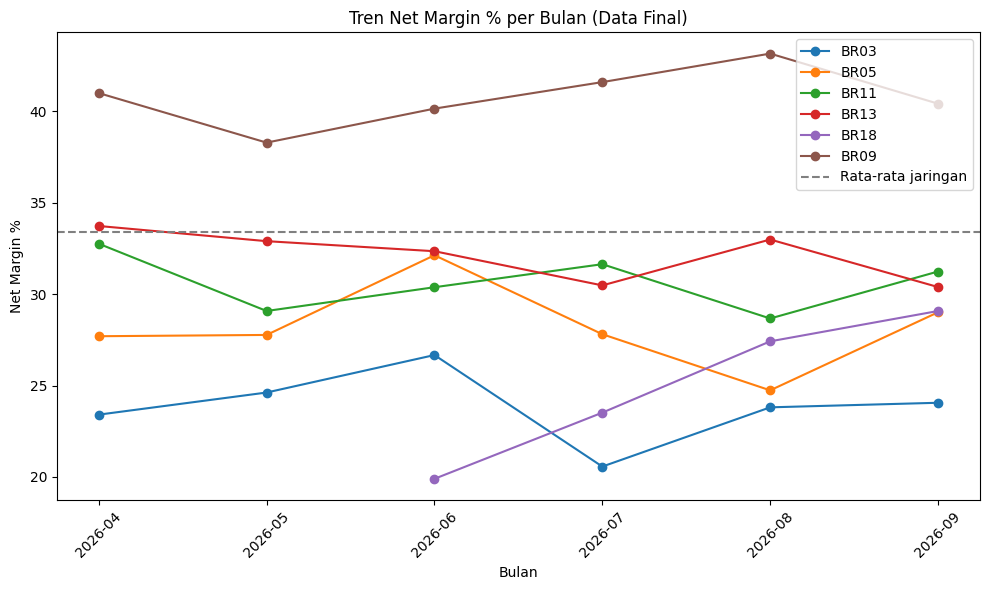

In [41]:
#1. Visualisasi Tren Net Margin per Bulan untuk Cabang Bermasalah
branches_to_check = ['BR03', 'BR05', 'BR11', 'BR13', 'BR18', 'BR09']

plt.figure(figsize=(10, 6))
for b in branches_to_check:
    subset = kpi[kpi['branch_id'] == b].sort_values('month')
    plt.plot(subset['month'], subset['net_margin_pct'], marker='o', label=b)

plt.axhline(y=kpi['net_margin_pct'].mean(), color='gray', linestyle='--', label='Rata-rata jaringan')
plt.title('Tren Net Margin % per Bulan (Data Final)')
plt.xlabel('Bulan')
plt.ylabel('Net Margin %')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Temuan Utama

1. RANTING - Cinere (BR09) adalah cabang dengan performa terbaik dan paling konsisten

Margin cabang ini selalu berada jauh di atas rata-rata jaringan di setiap bulan tanpa kecuali, berkisar 38-43%. Ini bukan keberuntungan satu bulan, tapi pola yang stabil sepanjang periode. Cabang ini layak dijadikan contoh praktik terbaik untuk disebarkan ke cabang lain.

2. RANTING - Summarecon Bekasi (BR18), cabang yang baru dibuka Juni 2026, menunjukkan pertumbuhan yang sehat

Margin cabang ini naik konsisten setiap bulan sejak dibuka: dari 19,9% di bulan pertama menjadi 29,1% di bulan keempat. Pola ini normal dan diharapkan untuk cabang baru yang sedang membangun basis pelanggan dan efisiensi operasional. Tidak memerlukan intervensi, cukup dipantau untuk memastikan tren positif ini berlanjut.

3. Empat cabang menunjukkan margin di bawah rata-rata secara konsisten

RANTING - Kelapa Gading (BR03), RANTING - BSD (BR05), RANTING - Tangerang (BR11), dan RANTING - Sentul (BR13) berada di bawah garis rata-rata jaringan di hampir semua bulan. Ini bukan penurunan satu bulan yang kebetulan, tapi pola berulang, artinya ada masalah struktural yang perlu ditangani, bukan sekadar fluktuasi musiman.

4. RANTING - Kelapa Gading (BR03) memerlukan perhatian paling segera

Cabang ini konsisten menjadi yang terendah atau kedua terendah di hampir semua bulan (20-27%), dengan titik terendah di Juli (20,6%). Analisis lebih lanjut menunjukkan penyebabnya adalah struktur biaya tenaga kerja yang terlalu tinggi dibanding cabang lain, bukan masalah pada penjualan atau bahan baku.

In [42]:
#2. Investigasi Anomali Bulanan (BR05 di Juni, BR03 di September)
#Pertama tama Cek BR05 khusus bulan Juni: sourcing dan waste-nya seperti apa dibanding bulan lain
br05_sourcing = sourcing_check[sourcing_check['branch_id'] == 'BR05'].copy()
br05_sourcing['month'] = pd.to_datetime(purchases[purchases['branch_id']=='BR05']['month']).dt.to_period('M').astype(str) if False else None

#Supaya lebih akurat, pakai purchases langsung karena sudah ada kolom month:
br05_purchases = purchases[purchases['branch_id'] == 'BR05'].merge(
    ingredients[['ingredient_id', 'standard_cost']], on='ingredient_id'
)
br05_purchases['cost_ratio'] = br05_purchases['unit_cost'] / br05_purchases['standard_cost']

print("Rata-rata cost_ratio BR05 per bulan:")
print(br05_purchases.groupby('month')['cost_ratio'].mean().round(3))

br05_waste = inventory[inventory['branch_id'] == 'BR05']
print("\nRata-rata waste_pct BR05 per bulan:")
print(br05_waste.groupby('month')['waste_pct'].mean().round(2))

Rata-rata cost_ratio BR05 per bulan:
month
2026-04-01    1.248
2026-05-01    1.227
2026-06-01    1.243
2026-07-01    1.219
2026-08-01    1.247
2026-09-01    1.243
Name: cost_ratio, dtype: float64

Rata-rata waste_pct BR05 per bulan:
month
2026-04-01    5.34
2026-05-01    5.54
2026-06-01    5.71
2026-07-01    4.90
2026-08-01    5.70
2026-09-01    6.09
Name: waste_pct, dtype: float64


In [43]:
br05_full = kpi[kpi['branch_id'] == 'BR05'][
    ['month', 'revenue', 'cogs_used', 'labor_cost', 'rent_cost', 'marketing_cost', 'utilities_cost', 'net_margin_pct']
].copy()
for col in ['cogs_used', 'labor_cost', 'rent_cost', 'marketing_cost', 'utilities_cost']:
    br05_full[col + '_pct'] = (br05_full[col] / br05_full['revenue'] * 100).round(2)
print(br05_full[['month', 'cogs_used_pct', 'labor_cost_pct', 'rent_cost_pct', 'marketing_cost_pct', 'utilities_cost_pct']])

      month  cogs_used_pct  labor_cost_pct  rent_cost_pct  marketing_cost_pct  \
24  2026-04          36.91           20.12          10.41                1.62   
25  2026-05          35.30           19.88          11.37                2.72   
26  2026-06          36.14           17.96           9.94                1.34   
27  2026-07          34.46           19.60          12.21                2.68   
28  2026-08          36.60           19.99          12.47                2.98   
29  2026-09          36.71           20.08           9.52                1.70   

    utilities_cost_pct  
24                3.24  
25                2.97  
26                2.48  
27                3.24  
28                3.23  
29                2.99  


In [44]:
# cek BR03 di September dengan pola yang sama
br03_full = kpi[kpi['branch_id'] == 'BR03'][
    ['month', 'revenue', 'cogs_used', 'labor_cost', 'rent_cost', 'marketing_cost', 'utilities_cost', 'net_margin_pct']
].copy()
for col in ['cogs_used', 'labor_cost', 'rent_cost', 'marketing_cost', 'utilities_cost']:
    br03_full[col + '_pct'] = (br03_full[col] / br03_full['revenue'] * 100).round(2)
print(br03_full[['month', 'revenue', 'net_margin_pct']])
print(br03_full[['month', 'cogs_used_pct', 'labor_cost_pct', 'rent_cost_pct', 'marketing_cost_pct', 'utilities_cost_pct']])

      month   revenue  net_margin_pct
12  2026-04  49313000           23.41
13  2026-05  51075000           24.62
14  2026-06  49206500           26.67
15  2026-07  48407000           20.57
16  2026-08  57020000           23.81
17  2026-09  31012500           24.06
      month  cogs_used_pct  labor_cost_pct  rent_cost_pct  marketing_cost_pct  \
12  2026-04          28.16           30.98          11.65                3.30   
13  2026-05          29.01           29.99          10.10                3.04   
14  2026-06          28.54           30.83           9.55                1.13   
15  2026-07          29.91           31.70          12.15                2.59   
16  2026-08          29.38           29.55          11.68                2.37   
17  2026-09          28.29           30.08          11.05                1.48   

    utilities_cost_pct  
12                2.49  
13                3.25  
14                3.27  
15                3.08  
16                3.21  
17              